# 07 Threshold Selection and Event-Level Evaluation

This notebook performs validation-threshold selection and test-set event-level evaluation for the MetroPT-3 framework.

Inputs:

- `outputs/predictions/validation_predictions_all_models.csv`
- `outputs/predictions/test_predictions_all_models.csv`

Outputs include threshold search tables, selected thresholds, event-level test results, alarm episodes and a best-model test timeline.

In [1]:
# 1. Imports and environment check

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve
)

print("Python executable:", sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Scripts\python.exe
pandas: 2.2.2
numpy: 1.26.4


## 1. Project paths

In [2]:
# 2. Define project paths

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

validation_predictions_path = OUTPUT_PREDICTIONS_DIR / "validation_predictions_all_models.csv"
test_predictions_path = OUTPUT_PREDICTIONS_DIR / "test_predictions_all_models.csv"

print("Project root:", PROJECT_ROOT)
print("Validation predictions:", validation_predictions_path)
print("Test predictions:", test_predictions_path)

Project root: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter
Validation predictions: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\outputs\predictions\validation_predictions_all_models.csv
Test predictions: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\metropt_predictive_maintenance_starter\outputs\predictions\test_predictions_all_models.csv


## 2. Load validation and test predictions

In [3]:
# 3. Load predictions

if not validation_predictions_path.exists():
    raise FileNotFoundError("validation_predictions_all_models.csv not found. Run Step 6 first.")

if not test_predictions_path.exists():
    raise FileNotFoundError("test_predictions_all_models.csv not found. Run Step 6 first.")

val_pred = pd.read_csv(validation_predictions_path)
test_pred = pd.read_csv(test_predictions_path)

if "timestamp" not in val_pred.columns or "timestamp" not in test_pred.columns:
    raise ValueError("timestamp column missing from prediction files. Rerun Step 6 with metadata included.")

val_pred["timestamp"] = pd.to_datetime(val_pred["timestamp"], errors="coerce")
test_pred["timestamp"] = pd.to_datetime(test_pred["timestamp"], errors="coerce")

val_pred = val_pred.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
test_pred = test_pred.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

for col in ["warning_12h_event_id", "failure_event_id"]:
    if col in val_pred.columns:
        val_pred[col] = val_pred[col].fillna("None").astype(str)
    if col in test_pred.columns:
        test_pred[col] = test_pred[col].fillna("None").astype(str)

print("Validation predictions shape:", val_pred.shape)
print("Test predictions shape:", test_pred.shape)
print("Validation period:", val_pred["timestamp"].min(), "to", val_pred["timestamp"].max())
print("Test period:", test_pred["timestamp"].min(), "to", test_pred["timestamp"].max())

print("\nValidation warning events:")
print(val_pred["warning_12h_event_id"].value_counts().head(10) if "warning_12h_event_id" in val_pred.columns else "Missing")

print("\nTest warning events:")
print(test_pred["warning_12h_event_id"].value_counts().head(10) if "warning_12h_event_id" in test_pred.columns else "Missing")

C:\Users\user\AppData\Local\Temp\ipykernel_16488\1412812015.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  val_pred = pd.read_csv(validation_predictions_path)
C:\Users\user\AppData\Local\Temp\ipykernel_16488\1412812015.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  test_pred = pd.read_csv(test_predictions_path)


Validation predictions shape: (262969, 12)
Test predictions shape: (348590, 12)
Validation period: 2020-06-04 22:00:06 to 2020-07-15 02:29:57
Test period: 2020-07-15 02:30:07 to 2020-09-01 03:59:50

Validation warning events:
warning_12h_event_id
None    258611
F3        4358
Name: count, dtype: int64

Test warning events:
warning_12h_event_id
None    344233
F4        4357
Name: count, dtype: int64


## 3. Define failure events and model score columns

In [4]:
# 4. Define failure events and score columns

failure_events = pd.DataFrame({
    "event_id": ["F1", "F2", "F3", "F4"],
    "failure_type": ["Air leak", "Air leak", "Air leak", "Air leak"],
    "failure_start": [
        "2020-04-18 00:00",
        "2020-05-29 23:30",
        "2020-06-05 10:00",
        "2020-07-15 14:30"
    ],
    "failure_end": [
        "2020-04-18 23:59",
        "2020-05-30 06:00",
        "2020-06-07 14:30",
        "2020-07-15 19:00"
    ]
})

failure_events["failure_start"] = pd.to_datetime(failure_events["failure_start"])
failure_events["failure_end"] = pd.to_datetime(failure_events["failure_end"])
failure_events["warning_12h_start"] = failure_events["failure_start"] - pd.Timedelta(hours=12)
failure_events["warning_12h_end"] = failure_events["failure_start"] - pd.Timedelta(seconds=1)

score_columns = [col for col in val_pred.columns if col.endswith("_score")]
if not score_columns:
    raise ValueError("No model score columns found. Run Step 6 again.")

model_name_map = {
    "logistic_regression_score": "Logistic Regression",
    "random_forest_score": "Random Forest",
    "xgboost_score": "XGBoost",
    "isolation_forest_score": "Isolation Forest"
}

print("Score columns found:")
for col in score_columns:
    print("-", col, "=>", model_name_map.get(col, col))

Score columns found:
- logistic_regression_score => Logistic Regression
- random_forest_score => Random Forest
- xgboost_score => XGBoost
- isolation_forest_score => Isolation Forest


## 4. Helper functions

In [7]:
# 5. Helper functions

MERGE_GAP_MINUTES = 10
MIN_ALARM_DURATION_MINUTES = 5


def safe_pr_auc(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan


def safe_roc_auc(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def record_level_metrics(y_true, y_score, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    y_pred = np.asarray(y_pred).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "pr_auc": safe_pr_auc(y_true, y_score),
        "roc_auc": safe_roc_auc(y_true, y_score),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    }


def create_alarm_episodes(data, pred_col):
    episode_columns = [
        "episode_id",
        "episode_start",
        "episode_end",
        "duration_minutes",
        "positive_points",
        "overlaps_warning_window",
        "event_ids_overlapped"
    ]

    positives = data[data[pred_col] == 1][
        ["timestamp", "y_true", "warning_12h_event_id"]
    ].copy()

    if positives.empty:
        return pd.DataFrame(columns=episode_columns)

    positives = positives.sort_values("timestamp").reset_index(drop=True)

    time_gap = positives["timestamp"].diff()
    new_episode = time_gap.isna() | (
        time_gap > pd.Timedelta(minutes=MERGE_GAP_MINUTES)
    )

    positives["episode_id"] = new_episode.cumsum()

    episode_records = []

    for episode_id, group in positives.groupby("episode_id"):
        start = group["timestamp"].min()
        end = group["timestamp"].max()

        duration_minutes = max(
            (end - start).total_seconds() / 60,
            0
        )

        event_ids = sorted([
            x for x in group["warning_12h_event_id"].dropna().unique().tolist()
            if str(x) != "None"
        ])

        overlaps_warning = len(event_ids) > 0

        # Ignore very short alarms unless they overlap an actual warning window.
        if duration_minutes < MIN_ALARM_DURATION_MINUTES and not overlaps_warning:
            continue

        episode_records.append({
            "episode_id": int(episode_id),
            "episode_start": start,
            "episode_end": end,
            "duration_minutes": duration_minutes,
            "positive_points": int(len(group)),
            "overlaps_warning_window": overlaps_warning,
            "event_ids_overlapped": ", ".join(event_ids) if event_ids else "None"
        })

    if len(episode_records) == 0:
        return pd.DataFrame(columns=episode_columns)

    return pd.DataFrame(episode_records, columns=episode_columns)


def evaluate_event_level(data, y_pred, events, model_name, threshold, split_name):
    working = data.copy()
    working["selected_prediction"] = np.asarray(y_pred).astype(int)
    episodes = create_alarm_episodes(working, "selected_prediction")
    split_start = working["timestamp"].min()
    split_end = working["timestamp"].max()
    operating_days = max((split_end - split_start).total_seconds() / (60 * 60 * 24), 1e-9)
    events_in_split = sorted([x for x in working["warning_12h_event_id"].dropna().unique().tolist() if str(x) != "None"])
    event_records = []
    for _, event in events.iterrows():
        event_id = event["event_id"]
        if event_id not in events_in_split:
            continue
        warning_start = event["warning_12h_start"]
        warning_end = event["warning_12h_end"]
        event_episodes = episodes[
            (episodes["episode_start"] >= warning_start) &
            (episodes["episode_start"] <= warning_end)
        ].copy()
        detected = len(event_episodes) > 0
        if detected:
            first_alert = event_episodes["episode_start"].min()
            lead_time_hours = (event["failure_start"] - first_alert).total_seconds() / 3600
        else:
            first_alert = pd.NaT
            lead_time_hours = np.nan
        event_records.append({
            "split": split_name,
            "model": model_name,
            "threshold": threshold,
            "event_id": event_id,
            "failure_start": event["failure_start"],
            "warning_start": warning_start,
            "detected": detected,
            "first_alert_time": first_alert,
            "lead_time_hours": lead_time_hours,
            "alarm_episodes_in_warning_window": len(event_episodes)
        })
    event_detection = pd.DataFrame(event_records)
    detected_events = int(event_detection["detected"].sum()) if not event_detection.empty else 0
    total_events = int(len(event_detection))
    true_alarm_episodes = int(episodes["overlaps_warning_window"].sum()) if not episodes.empty else 0
    total_alarm_episodes = int(len(episodes))
    false_alarm_episodes = total_alarm_episodes - true_alarm_episodes
    false_alarm_episodes_per_day = false_alarm_episodes / operating_days
    total_alarm_time_hours = episodes["duration_minutes"].sum() / 60 if not episodes.empty else 0
    detected_leads = event_detection[event_detection["detected"] == True]["lead_time_hours"] if not event_detection.empty else pd.Series(dtype=float)
    summary = {
        "split": split_name,
        "model": model_name,
        "threshold": threshold,
        "events_evaluated": total_events,
        "events_detected": detected_events,
        "events_missed": total_events - detected_events,
        "failure_detection_rate": detected_events / total_events if total_events > 0 else np.nan,
        "median_lead_time_hours": detected_leads.median() if len(detected_leads) > 0 else np.nan,
        "min_lead_time_hours": detected_leads.min() if len(detected_leads) > 0 else np.nan,
        "max_lead_time_hours": detected_leads.max() if len(detected_leads) > 0 else np.nan,
        "total_alarm_episodes": total_alarm_episodes,
        "true_alarm_episodes": true_alarm_episodes,
        "false_alarm_episodes": false_alarm_episodes,
        "false_alarm_episodes_per_day": false_alarm_episodes_per_day,
        "total_alarm_time_hours": total_alarm_time_hours,
        "median_alarm_duration_minutes": episodes["duration_minutes"].median() if not episodes.empty else np.nan,
        "max_alarm_duration_minutes": episodes["duration_minutes"].max() if not episodes.empty else np.nan,
        "alert_episode_precision": true_alarm_episodes / total_alarm_episodes if total_alarm_episodes > 0 else np.nan
    }
    return summary, event_detection, episodes

## 5. Validation threshold search

In [8]:
# 6. Validation threshold search

thresholds = np.round(np.arange(0.05, 0.951, 0.05), 2)
validation_threshold_records = []
validation_event_records = []

for score_col in score_columns:
    model_name = model_name_map.get(score_col, score_col.replace("_score", ""))
    print("Searching thresholds for:", model_name)
    for threshold in thresholds:
        y_true = val_pred["y_true"].astype(int).values
        y_score = val_pred[score_col].values
        y_pred = (y_score >= threshold).astype(int)
        rec_metrics = record_level_metrics(y_true, y_score, y_pred)
        event_summary, event_detection, episodes = evaluate_event_level(
            val_pred, y_pred, failure_events, model_name, threshold, "validation"
        )
        row = {
            "score_column": score_col,
            "model": model_name,
            "threshold": threshold,
            **rec_metrics,
            **{k: v for k, v in event_summary.items() if k not in ["split", "model", "threshold"]}
        }
        validation_threshold_records.append(row)
        if not event_detection.empty:
            validation_event_records.append(event_detection)

validation_threshold_search = pd.DataFrame(validation_threshold_records)
validation_threshold_search.to_csv(OUTPUT_TABLES_DIR / "validation_threshold_search.csv", index=False)

if validation_event_records:
    validation_event_detail = pd.concat(validation_event_records, ignore_index=True)
else:
    validation_event_detail = pd.DataFrame()

validation_event_detail.to_csv(OUTPUT_TABLES_DIR / "validation_event_detection_detail_all_thresholds.csv", index=False)
validation_threshold_search.head()

Searching thresholds for: Logistic Regression
Searching thresholds for: Random Forest
Searching thresholds for: XGBoost
Searching thresholds for: Isolation Forest


,score_column,model,threshold,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,...,min_lead_time_hours,max_lead_time_hours,total_alarm_episodes,true_alarm_episodes,false_alarm_episodes,false_alarm_episodes_per_day,total_alarm_time_hours,median_alarm_duration_minutes,max_alarm_duration_minutes,alert_episode_precision
0,logistic_regression_score,Logistic Regression,0.05,0.019876,1.000000,0.038978,0.092061,0.011186,0.305266,43711,...,11.998333,11.998333,59,1,58,1.443239,620.975833,266.283333,5787.800000,0.016949
1,logistic_regression_score,Logistic Regression,0.10,0.020082,0.999541,0.039372,0.092939,0.011186,0.305266,46051,...,11.998333,11.998333,64,1,63,1.567656,615.249722,201.891667,5787.300000,0.015625
2,logistic_regression_score,Logistic Regression,0.15,0.020116,0.994952,0.039435,0.093056,0.011186,0.305266,47401,...,11.998333,11.998333,63,1,62,1.542772,611.379444,233.783333,5787.300000,0.015873
3,logistic_regression_score,Logistic Regression,0.20,0.020112,0.989674,0.039424,0.093002,0.011186,0.305266,48480,...,11.998333,11.998333,62,1,61,1.517889,609.363333,237.325000,5786.466667,0.016129
4,logistic_regression_score,Logistic Regression,0.25,0.020040,0.981184,0.039277,0.092630,0.011186,0.305266,49509,...,11.998333,11.998333,65,1,64,1.592539,606.754444,220.733333,5786.466667,0.015385


## 6. Select validation thresholds

In [9]:
# 7. Select threshold for each model

selected_threshold_records = []

for model_name, group in validation_threshold_search.groupby("model"):
    valid_group = group.copy()
    constrained = valid_group[valid_group["false_alarm_episodes_per_day"] <= 1.0].copy()
    if constrained.empty:
        constrained = valid_group.sort_values(
            by=["false_alarm_episodes_per_day", "f2", "failure_detection_rate", "median_lead_time_hours"],
            ascending=[True, False, False, False]
        ).head(1).copy()
        selection_note = "No threshold met <=1 false alarm episode/day; selected lowest false-alarm option."
    else:
        constrained = constrained.sort_values(
            by=["f2", "failure_detection_rate", "median_lead_time_hours", "pr_auc"],
            ascending=[False, False, False, False]
        ).head(1).copy()
        selection_note = "Selected by max validation F2 subject to <=1 false alarm episode/day."
    selected = constrained.iloc[0].to_dict()
    selected["selection_note"] = selection_note
    selected_threshold_records.append(selected)

selected_thresholds = pd.DataFrame(selected_threshold_records)
selected_thresholds.to_csv(OUTPUT_TABLES_DIR / "selected_thresholds_from_validation.csv", index=False)
selected_thresholds

,score_column,model,threshold,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,...,max_lead_time_hours,total_alarm_episodes,true_alarm_episodes,false_alarm_episodes,false_alarm_episodes_per_day,total_alarm_time_hours,median_alarm_duration_minutes,max_alarm_duration_minutes,alert_episode_precision,selection_note
0,isolation_forest_score,Isolation Forest,0.05,0.013884,0.763424,0.027273,0.064714,0.010634,0.302131,22317,...,11.998333,39,1,38,0.945570,738.868333,757.866667,5555.633333,0.025641,Selected by max validation F2 subject to <=1 f...
1,logistic_regression_score,Logistic Regression,0.05,0.019876,1.000000,0.038978,0.092061,0.011186,0.305266,43711,...,11.998333,59,1,58,1.443239,620.975833,266.283333,5787.800000,0.016949,No threshold met <=1 false alarm episode/day; ...
2,random_forest_score,Random Forest,0.20,0.001382,0.002983,0.001889,0.002422,0.013503,0.400306,249220,...,0.180556,21,1,20,0.497668,30.286944,23.300000,844.733333,0.047619,Selected by max validation F2 subject to <=1 f...
3,xgboost_score,XGBoost,0.10,0.000000,0.000000,0.000000,0.000000,0.017790,0.544798,253556,...,NaN,8,0,8,0.199067,16.498889,21.141667,844.733333,0.000000,Selected by max validation F2 subject to <=1 f...


## 7. Select best overall model from validation

In [10]:
# 8. Select best validation model

best_model_selection = selected_thresholds.sort_values(
    by=["f2", "failure_detection_rate", "median_lead_time_hours", "pr_auc"],
    ascending=[False, False, False, False]
).head(1).copy()

best_model_selection.to_csv(OUTPUT_TABLES_DIR / "best_model_selection_from_validation.csv", index=False)

best_model_name = best_model_selection["model"].iloc[0]
best_threshold = float(best_model_selection["threshold"].iloc[0])
best_score_col = best_model_selection["score_column"].iloc[0]

print("Best validation model:", best_model_name)
print("Selected threshold:", best_threshold)
print("Score column:", best_score_col)

best_model_selection

Best validation model: Logistic Regression
Selected threshold: 0.05
Score column: logistic_regression_score


,score_column,model,threshold,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,...,max_lead_time_hours,total_alarm_episodes,true_alarm_episodes,false_alarm_episodes,false_alarm_episodes_per_day,total_alarm_time_hours,median_alarm_duration_minutes,max_alarm_duration_minutes,alert_episode_precision,selection_note
1,logistic_regression_score,Logistic Regression,0.05,0.019876,1.0,0.038978,0.092061,0.011186,0.305266,43711,...,11.998333,59,1,58,1.443239,620.975833,266.283333,5787.8,0.016949,No threshold met <=1 false alarm episode/day; ...


## 8. Plot validation threshold trade-offs

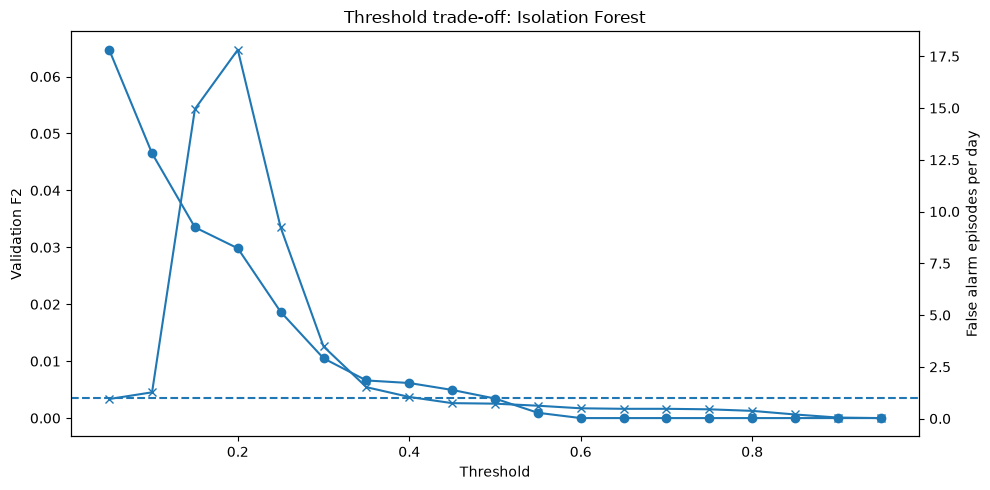

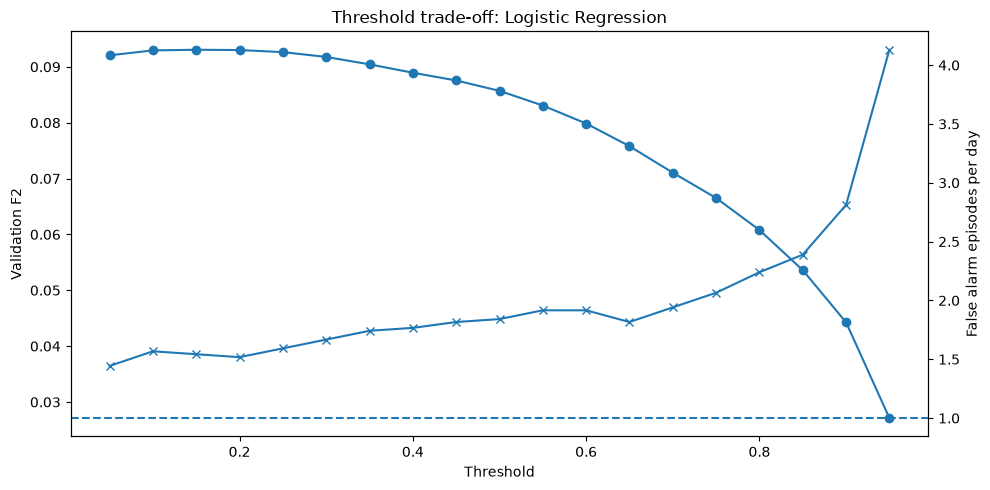

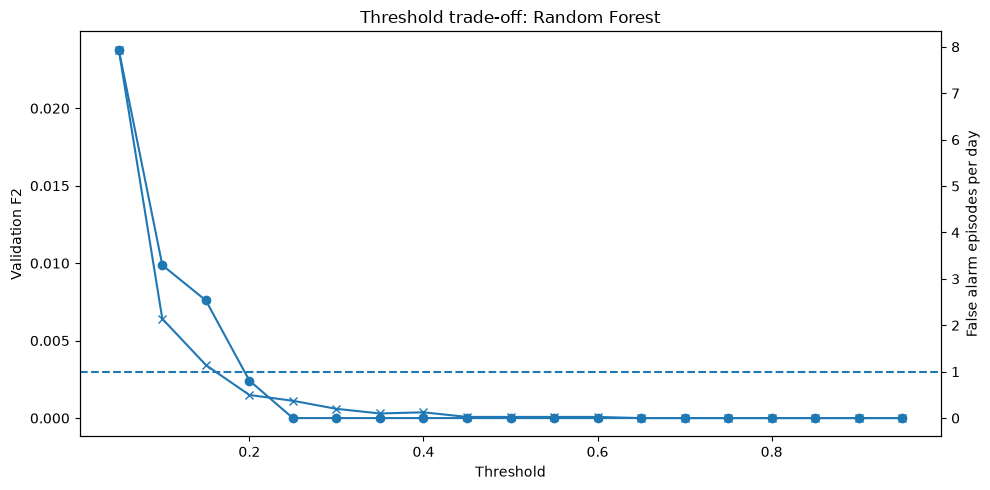

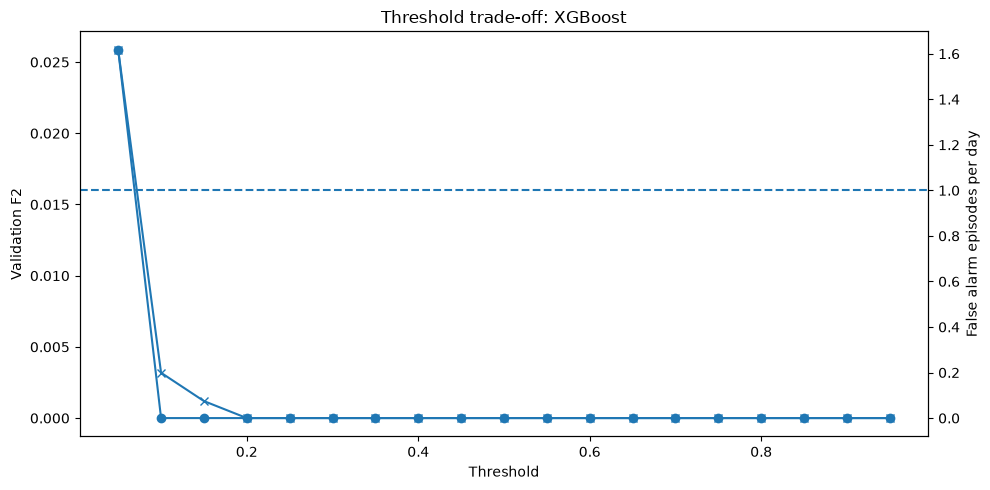

In [11]:
# 9. Plot threshold trade-offs

for model_name, group in validation_threshold_search.groupby("model"):
    group = group.sort_values("threshold")
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(group["threshold"], group["f2"], marker="o", label="F2")
    ax1.set_xlabel("Threshold")
    ax1.set_ylabel("Validation F2")
    ax1.set_title(f"Threshold trade-off: {model_name}")
    ax2 = ax1.twinx()
    ax2.plot(group["threshold"], group["false_alarm_episodes_per_day"], marker="x", label="False alarms/day")
    ax2.axhline(1.0, linestyle="--", label="1 false alarm/day limit")
    ax2.set_ylabel("False alarm episodes per day")
    fig.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(OUTPUT_FIGURES_DIR / f"threshold_tradeoff_{safe_name}.png", dpi=300)
    plt.show()

## 9. Evaluate selected thresholds on test data

In [12]:
# 10. Evaluate selected thresholds on test set

test_summary_records = []
test_event_detail_records = []
test_episode_records = []
test_record_records = []
test_predictions_selected = test_pred.copy()

for _, selected in selected_thresholds.iterrows():
    model_name = selected["model"]
    score_col = selected["score_column"]
    threshold = float(selected["threshold"])
    y_true = test_pred["y_true"].astype(int).values
    y_score = test_pred[score_col].values
    y_pred = (y_score >= threshold).astype(int)
    pred_col = f"{model_name.lower().replace(' ', '_')}_selected_prediction"
    test_predictions_selected[pred_col] = y_pred
    rec_metrics = record_level_metrics(y_true, y_score, y_pred)
    event_summary, event_detection, episodes = evaluate_event_level(
        test_pred, y_pred, failure_events, model_name, threshold, "test"
    )
    test_summary_records.append({"score_column": score_col, **rec_metrics, **event_summary})
    test_record_records.append({"split": "test", "model": model_name, "threshold": threshold, **rec_metrics})
    if not event_detection.empty:
        test_event_detail_records.append(event_detection)
    if not episodes.empty:
        episodes_copy = episodes.copy()
        episodes_copy["split"] = "test"
        episodes_copy["model"] = model_name
        episodes_copy["threshold"] = threshold
        test_episode_records.append(episodes_copy)

test_event_level_results = pd.DataFrame(test_summary_records).sort_values(
    by=["f2", "failure_detection_rate", "median_lead_time_hours"],
    ascending=[False, False, False]
)

test_record_level_results = pd.DataFrame(test_record_records).sort_values(
    by=["f2", "pr_auc"],
    ascending=[False, False]
)

test_event_detection_detail = pd.concat(test_event_detail_records, ignore_index=True) if test_event_detail_records else pd.DataFrame()
test_alarm_episodes = pd.concat(test_episode_records, ignore_index=True) if test_episode_records else pd.DataFrame()

test_event_level_results.to_csv(OUTPUT_TABLES_DIR / "test_event_level_results_selected_thresholds.csv", index=False)
test_record_level_results.to_csv(OUTPUT_TABLES_DIR / "test_record_level_results_selected_thresholds.csv", index=False)
test_event_detection_detail.to_csv(OUTPUT_TABLES_DIR / "test_event_detection_detail_selected_thresholds.csv", index=False)
test_alarm_episodes.to_csv(OUTPUT_TABLES_DIR / "test_alarm_episodes_selected_thresholds.csv", index=False)
test_predictions_selected.to_csv(OUTPUT_PREDICTIONS_DIR / "test_predictions_selected_thresholds.csv", index=False)

test_event_level_results

,score_column,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,false_positive,false_negative,...,min_lead_time_hours,max_lead_time_hours,total_alarm_episodes,true_alarm_episodes,false_alarm_episodes,false_alarm_episodes_per_day,total_alarm_time_hours,median_alarm_duration_minutes,max_alarm_duration_minutes,alert_episode_precision
0,isolation_forest_score,0.013424,1.0,0.026492,0.063698,0.163765,0.969781,24013,320220,0,...,11.998056,11.998056,48,1,47,0.977897,963.604167,1025.700000,9566.716667,0.020833
1,logistic_regression_score,0.000000,0.0,0.000000,0.000000,0.006347,0.012043,16417,327816,4357,...,NaN,NaN,57,0,57,1.185961,910.336944,943.216667,5057.350000,0.000000
2,random_forest_score,0.000000,0.0,0.000000,0.000000,0.009376,0.208226,314134,30099,4357,...,NaN,NaN,107,0,107,2.226277,103.450278,31.733333,749.083333,0.000000
3,xgboost_score,0.000000,0.0,0.000000,0.000000,0.018843,0.665200,339362,4871,4357,...,NaN,NaN,22,0,22,0.457739,15.136667,23.125000,329.850000,0.000000


## 10. Best-model test alarm timeline

C:\Users\user\AppData\Local\Temp\ipykernel_16488\4148042547.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16488\4148042547.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(OUTPUT_FIGURES_DIR / "test_alarm_timeline_best_model.png", dpi=300)
c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


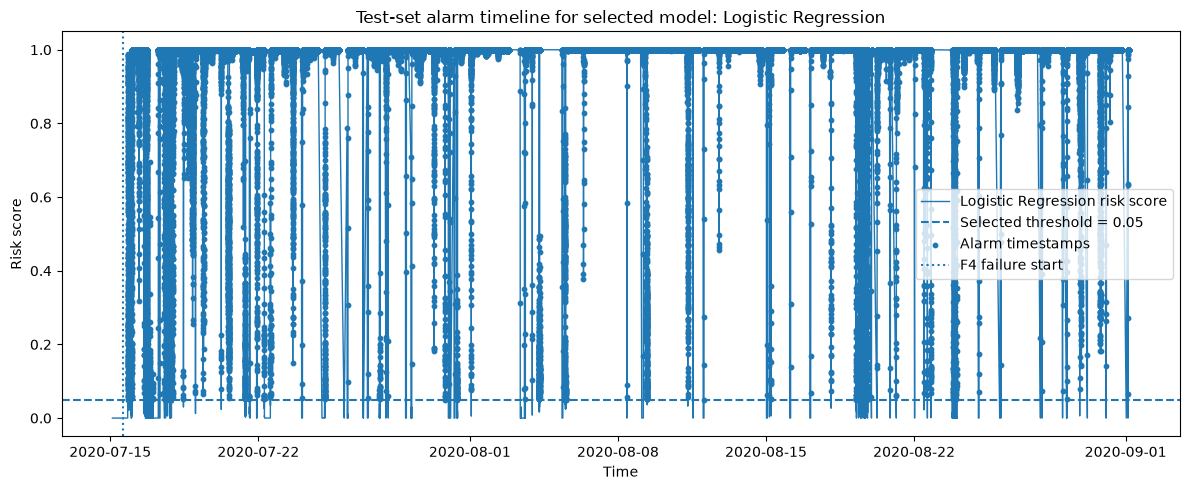

In [13]:
# 11. Plot best model test alarm timeline

best_test = test_pred.copy()
best_test["selected_prediction"] = (best_test[best_score_col].values >= best_threshold).astype(int)

plt.figure(figsize=(12, 5))
plt.plot(best_test["timestamp"], best_test[best_score_col], linewidth=1, label=f"{best_model_name} risk score")
plt.axhline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.2f}")

alarm_points = best_test[best_test["selected_prediction"] == 1]
if not alarm_points.empty:
    plt.scatter(alarm_points["timestamp"], alarm_points[best_score_col], s=10, label="Alarm timestamps")

for _, event in failure_events.iterrows():
    if best_test["timestamp"].min() <= event["failure_start"] <= best_test["timestamp"].max():
        plt.axvline(event["failure_start"], linestyle=":", label=f"{event['event_id']} failure start")

plt.xlabel("Time")
plt.ylabel("Risk score")
plt.title(f"Test-set alarm timeline for selected model: {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "test_alarm_timeline_best_model.png", dpi=300)
plt.show()

## 11. Save final evaluation summary

In [14]:
# 12. Save summary and checklist

best_test_row = test_event_level_results[test_event_level_results["model"] == best_model_name]

final_evaluation_summary = pd.DataFrame({
    "item": [
        "Validation prediction rows",
        "Test prediction rows",
        "Models evaluated",
        "Threshold search range",
        "Threshold selection rule",
        "Best validation model",
        "Best validation threshold",
        "Test events evaluated for best model",
        "Test detected events for best model",
        "Test false alarm episodes per day for best model",
        "Next step"
    ],
    "value": [
        len(val_pred),
        len(test_pred),
        ", ".join(selected_thresholds["model"].tolist()),
        "0.05 to 0.95 in 0.05 intervals",
        "max validation F2 subject to <=1 false alarm episode/day; tie by event detection and lead time",
        best_model_name,
        best_threshold,
        best_test_row["events_evaluated"].iloc[0] if not best_test_row.empty else np.nan,
        best_test_row["events_detected"].iloc[0] if not best_test_row.empty else np.nan,
        best_test_row["false_alarm_episodes_per_day"].iloc[0] if not best_test_row.empty else np.nan,
        "Step 8 SHAP explainability and risk framework"
    ]
})

final_evaluation_summary.to_csv(OUTPUT_TABLES_DIR / "threshold_event_evaluation_summary.csv", index=False)

completion_checklist = pd.DataFrame({
    "task": [
        "Validation predictions loaded",
        "Test predictions loaded",
        "Threshold search completed",
        "Selected thresholds saved",
        "Best validation model selected",
        "Test record-level results saved",
        "Test event-level results saved",
        "Test alarm episodes saved",
        "Best-model test timeline saved"
    ],
    "status": ["Complete"] * 9
})

completion_checklist.to_csv(OUTPUT_TABLES_DIR / "threshold_event_evaluation_completion_checklist.csv", index=False)

final_evaluation_summary

,item,value
0,Validation prediction rows,262969
1,Test prediction rows,348590
2,Models evaluated,"Isolation Forest, Logistic Regression, Random ..."
3,Threshold search range,0.05 to 0.95 in 0.05 intervals
4,Threshold selection rule,max validation F2 subject to <=1 false alarm e...
5,Best validation model,Logistic Regression
6,Best validation threshold,0.05
7,Test events evaluated for best model,1
8,Test detected events for best model,0
9,Test false alarm episodes per day for best model,1.185961


## 12. Final confirmation

In [15]:
# 13. Final confirmation

print("Step 7 complete.")

print("\nKey saved tables:")
for name in [
    "validation_threshold_search.csv",
    "selected_thresholds_from_validation.csv",
    "best_model_selection_from_validation.csv",
    "test_event_level_results_selected_thresholds.csv",
    "test_record_level_results_selected_thresholds.csv",
    "test_alarm_episodes_selected_thresholds.csv",
    "threshold_event_evaluation_summary.csv"
]:
    print("-", name, (OUTPUT_TABLES_DIR / name).exists())

print("\nKey saved figures:")
for name in ["test_alarm_timeline_best_model.png"]:
    print("-", name, (OUTPUT_FIGURES_DIR / name).exists())

print("\nBest model:", best_model_name)
print("Best threshold:", best_threshold)

Step 7 complete.

Key saved tables:
- validation_threshold_search.csv True
- selected_thresholds_from_validation.csv True
- best_model_selection_from_validation.csv True
- test_event_level_results_selected_thresholds.csv True
- test_record_level_results_selected_thresholds.csv True
- test_alarm_episodes_selected_thresholds.csv True
- threshold_event_evaluation_summary.csv True

Key saved figures:
- test_alarm_timeline_best_model.png True

Best model: Logistic Regression
Best threshold: 0.05
